
#**NOTE: This program should be ran on GPU. To test this pokemon image classifer, please upload a picture of your pokemon (image should be png or jpg,and please pick one from the 6 this program classifies) at the end of the program. Also there is a google drive I shared with you where you could upload your own pictures of pokemon in bulk in order to clasify them, but this is quite tedious**.

Here's a link to a dataset of images: https://www.kaggle.com/datasets/bhawks/pokemon-generation-one-22k/discussion/377626.

# Some changes I made: Instead of identifying all 151 pokemon in Generation One, this program identifies only six pokemon: Bulbasaur, Charmander, Eevee Meowth, Pikachi, and Squirtle. The reason for this is because my GPU cannot handle training over 20000 images. However, on a better computer, this program can easily be trained over 20000 images. Also, I used two datasets. This is the other one: https://www.kaggle.com/datasets/phil417854/dataset-pokemon-gen-1

Resources used: fast.ai, https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html, Gemini for help with importing images from google drive,
https://www.youtube.com/watch?v=CtzfbUwrYGI

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import os

plt.imshow(image, origin='upper')
ax = plt.gca()


y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks[::-1])


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The FilteredImageClass is used to filter out images that arent RGB (I am guessing the other images are grayscale?). The reason for this is because warnings appear and I felt it would best to not use them for the training. Here's a screenshot of the warning: 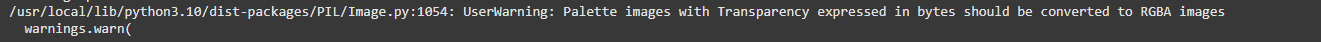

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# This class is used to filter out unsupported images (Pallete images or grayscale)
class FilteredImageFolder(torchvision.datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.filtered_samples = [
            sample for sample in self.samples
            if self.is_supported_image(sample[0])
        ]
        self.samples = self.filtered_samples

    def is_supported_image(self, image_path):
        try:
            with Image.open(image_path) as img:
                return img.mode == 'RGB'
        except Exception as e:
            print(f"Skipping invalid image: {image_path}, Error: {e}")
            return False

train_path='/content/drive/MyDrive/Datasets/Pokemon_Train'
test_path='/content/drive/MyDrive/Datasets/Pokemon_Test'

# Loading datasets
train_data = FilteredImageFolder(root=train_path, transform=transform)
test_data = FilteredImageFolder(root=test_path, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, num_workers = 2) #Edit batch size here
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False,  num_workers = 2) #Edit batch size here


In [ ]:
print(f'Training data size: {len(train_data)} images')
print(f'Test data size: {len(test_data)} images')

image, label = train_data[0]
image.size()

Training data size: 1190 images
Test data size: 700 images


torch.Size([3, 32, 32])

## After running this code, you will be able to see how the image is transformed in order for it to be inputted into the convolutional neural network.

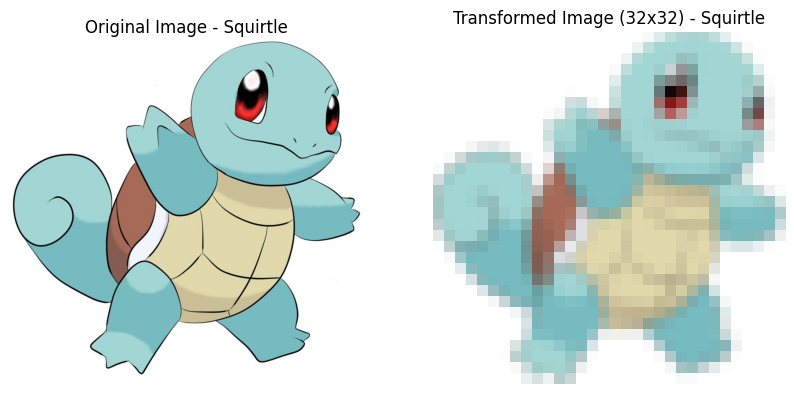

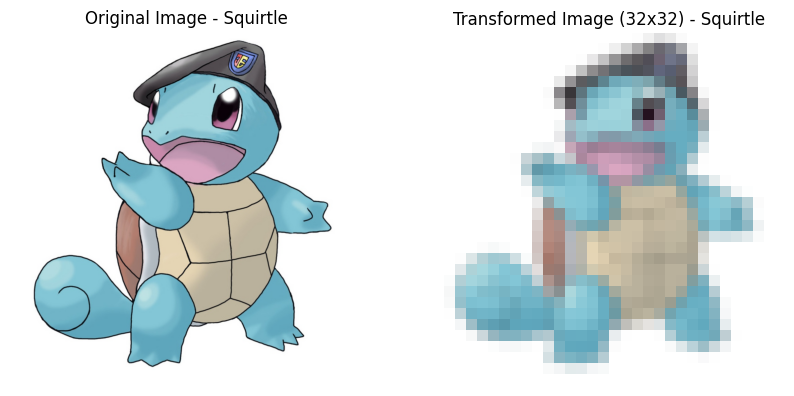

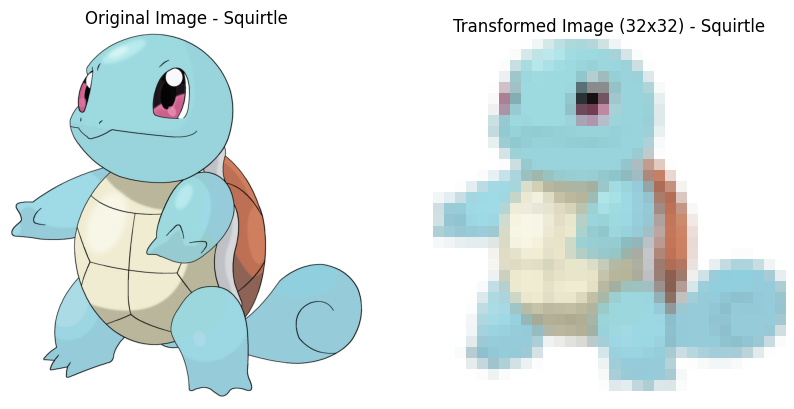

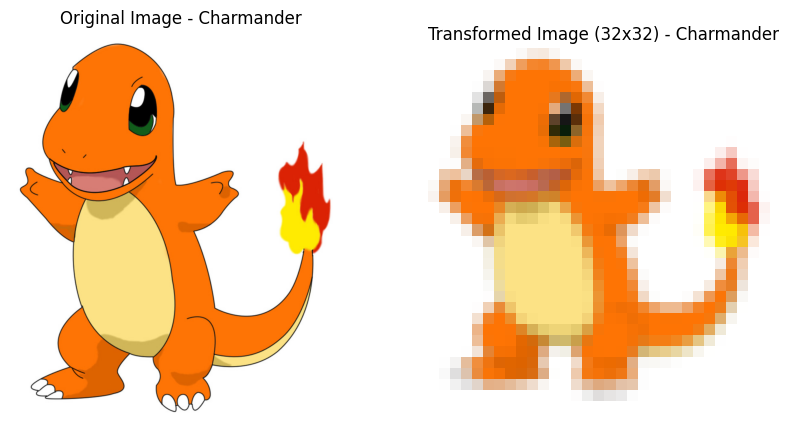

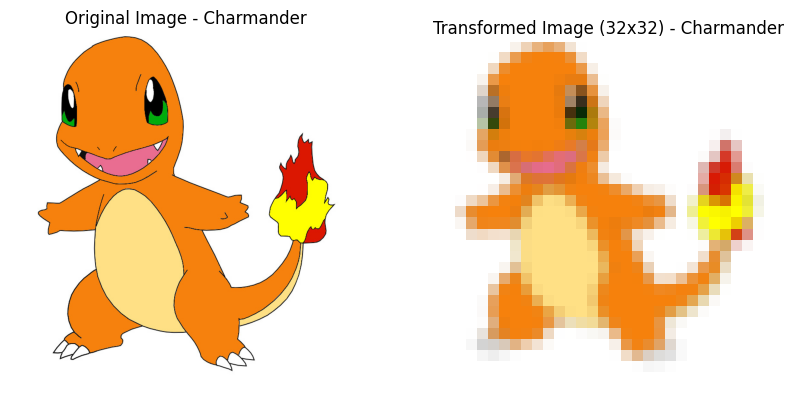

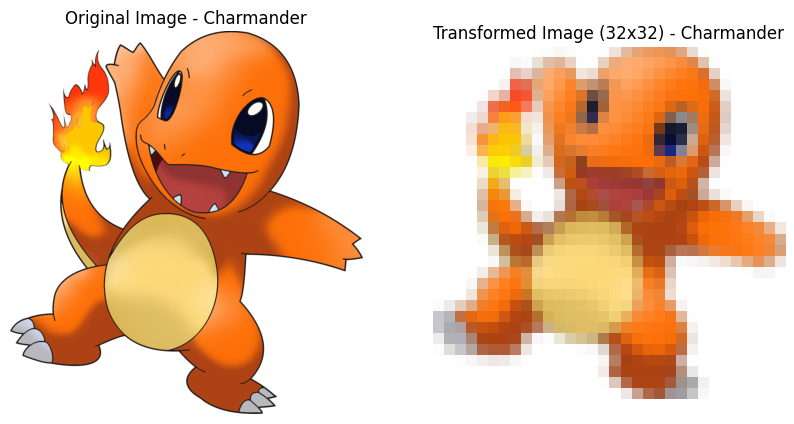

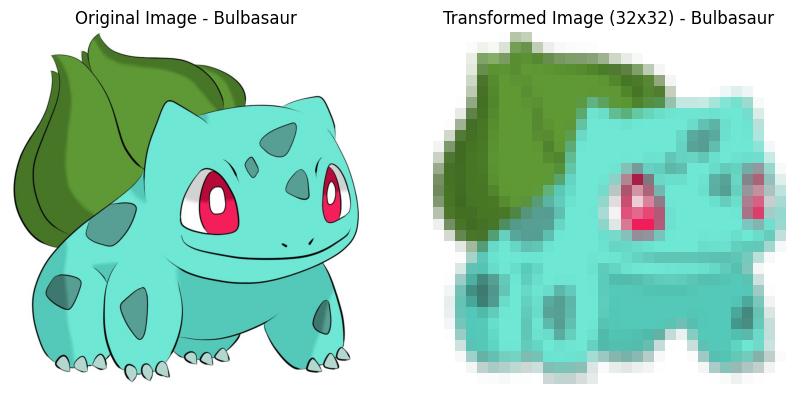

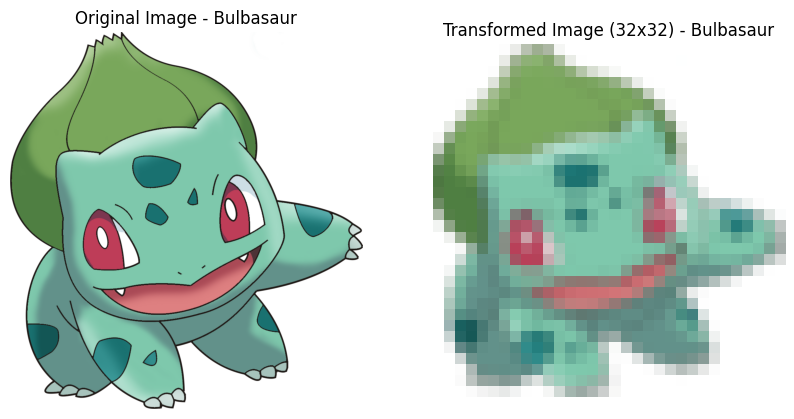

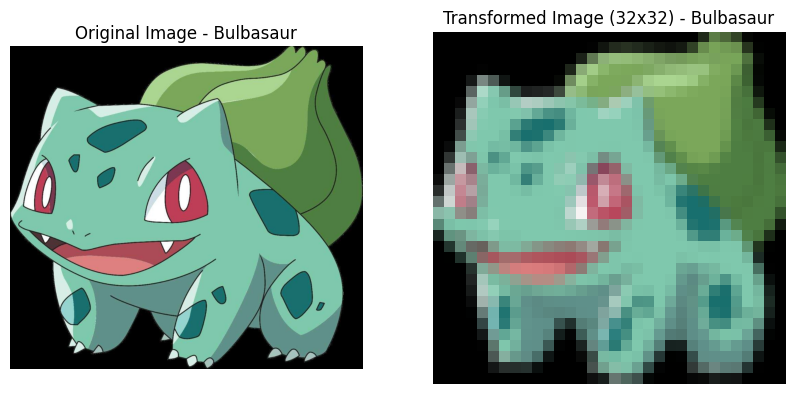

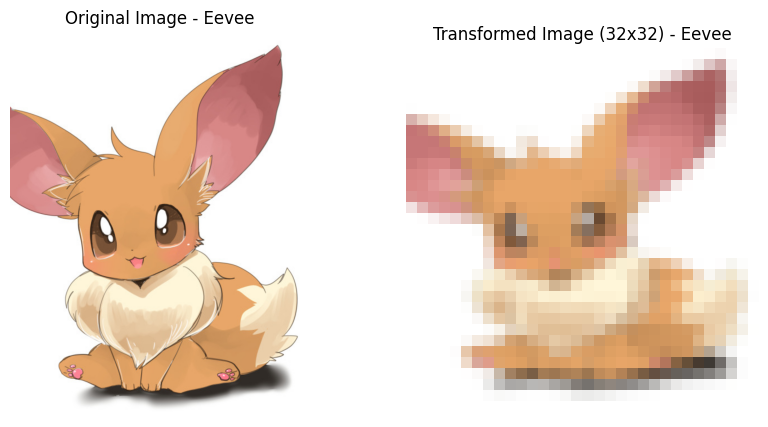

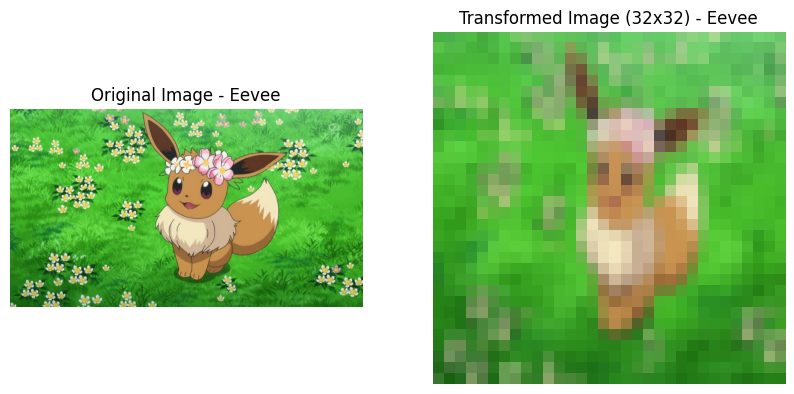

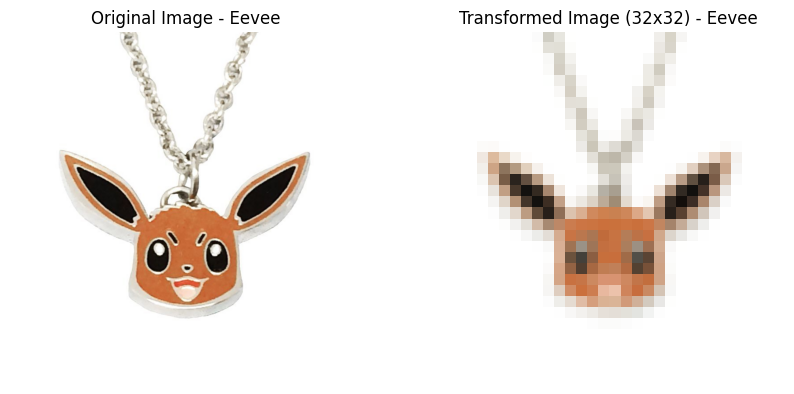

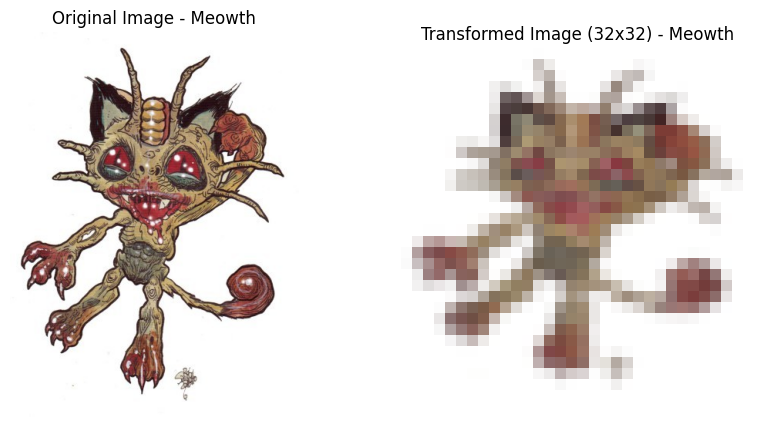

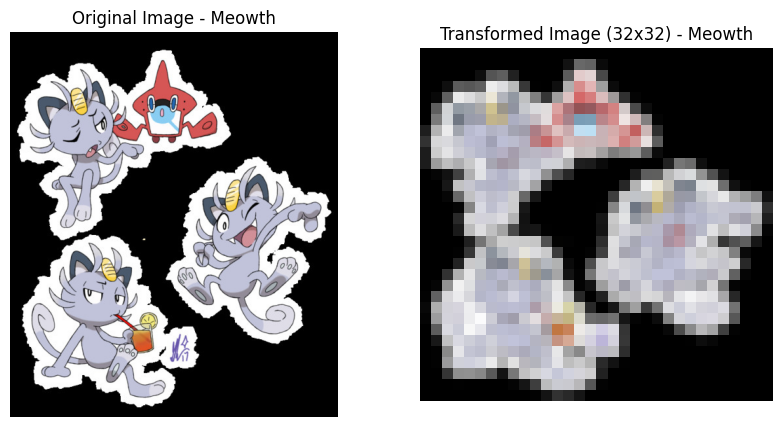

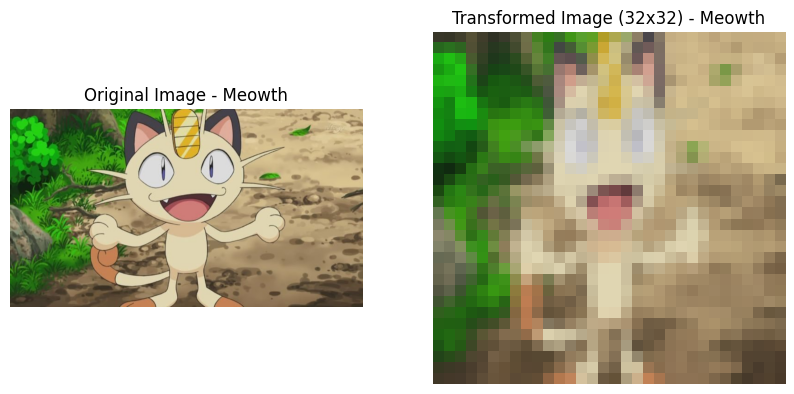

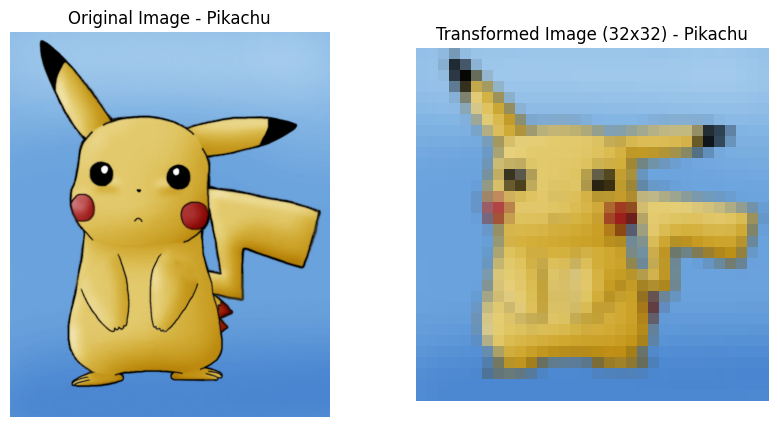

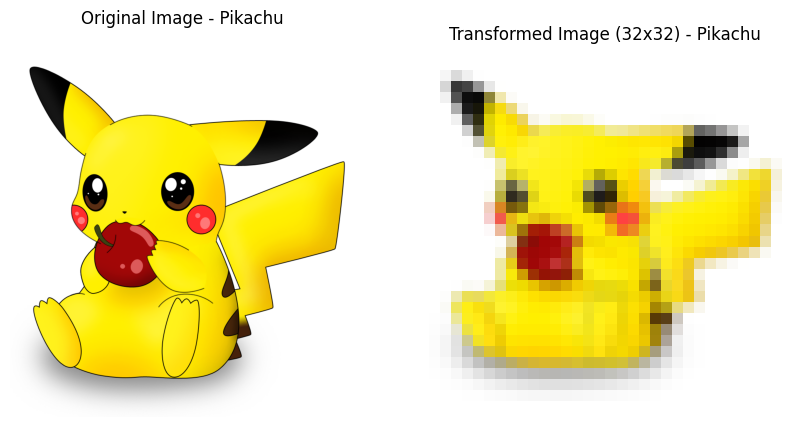

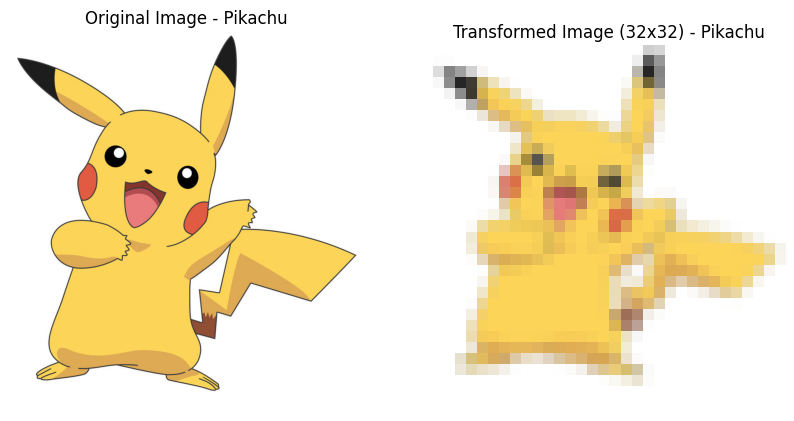

In [ ]:
def show_images_from_class(class_name, dataset, transform, num_images=5):
    """
    Display images from a specific folder (class) in the dataset.

    Args:
    - class_name: The name of the folder (class) to display images from.
    - dataset: The dataset loaded with `ImageFolder`.
    - transform: The transformation to apply to images.
    - num_images: Number of images to display from the folder.
    """

    class_idx = dataset.class_to_idx[class_name]
    class_samples = [sample for sample in dataset.samples if sample[1] == class_idx]

    if len(class_samples) == 0:
        print(f"No images found for class: {class_name}")
        return

    for i, (img_path, label) in enumerate(class_samples[:num_images]):
        original_image = Image.open(img_path)

        if original_image.mode != 'RGB':
            original_image = original_image.convert('RGB')

        transformed_image = transform(original_image)

        def denormalize(tensor, mean, std):
            tensor = tensor.clone()
            for t, m, s in zip(tensor, mean, std):
                t.mul_(s).add_(m)
            return tensor

        denormalized_image = denormalize(transformed_image.clone(), [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        denormalized_image = denormalized_image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(original_image)
        ax[0].set_title(f"Original Image - {class_name}")
        ax[0].axis("off")

        ax[1].imshow(denormalized_image)
        ax[1].set_title(f"Transformed Image (32x32) - {class_name}")
        ax[1].axis("off")

        plt.show()

# Example: Display 5 images from the next folder (class)
show_images_from_class("Squirtle", train_data, transform, num_images=3)
show_images_from_class("Charmander", train_data, transform, num_images=3)
show_images_from_class("Bulbasaur", train_data, transform, num_images=3)
show_images_from_class("Eevee", train_data, transform, num_images=3)
show_images_from_class("Meowth", train_data, transform, num_images=3)
show_images_from_class("Pikachu", train_data, transform, num_images=3)

In [ ]:
class_names = ['Bulbasaur', 'Charmander', 'Eevee', 'Meowth', 'Pikachu', 'Squirtle']

In [ ]:
class NeuralNet(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 12, 5) #(12, 28, 28)
    self.pool = nn.MaxPool2d(2, 2) #(12, 14, 14)
    self.conv2 = nn.Conv2d(12, 24, 5) #(24, 10, 10) -> (24, 5, 5) -> Flatten (24 * 5 * 5)
    self.fc1 = nn.Linear(24 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
net = NeuralNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Running this part of the code will take a while since the neural network is being trained. All the data is being traversed 50 times.

In [ ]:
for epoch in range(50):
  print(f'Training epoch {epoch + 1}...')

  running_loss = 0.0

  for i, data in enumerate(train_loader):
    inputs, labels = data

    optimizer.zero_grad()

    outputs = net(inputs)

    loss = loss_function(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f'Loss: {running_loss / len(train_loader):.4f}')


Training epoch 1...
Loss: 2.2747
Training epoch 2...
Loss: 2.1416
Training epoch 3...
Loss: 1.8190
Training epoch 4...
Loss: 1.6806
Training epoch 5...
Loss: 1.5939
Training epoch 6...
Loss: 1.5105
Training epoch 7...
Loss: 1.3369
Training epoch 8...
Loss: 1.1895
Training epoch 9...
Loss: 1.1265
Training epoch 10...
Loss: 1.0976
Training epoch 11...
Loss: 1.0272
Training epoch 12...
Loss: 0.9927
Training epoch 13...
Loss: 0.9233
Training epoch 14...
Loss: 0.9235
Training epoch 15...
Loss: 0.8594
Training epoch 16...
Loss: 0.8673
Training epoch 17...
Loss: 0.8160
Training epoch 18...
Loss: 0.8059
Training epoch 19...
Loss: 0.8085
Training epoch 20...
Loss: 0.7713
Training epoch 21...
Loss: 0.7625
Training epoch 22...
Loss: 0.7393
Training epoch 23...
Loss: 0.7172
Training epoch 24...
Loss: 0.6937
Training epoch 25...
Loss: 0.6915
Training epoch 26...
Loss: 0.6668
Training epoch 27...
Loss: 0.6597
Training epoch 28...
Loss: 0.6340
Training epoch 29...
Loss: 0.6022
Training epoch 30...
Lo

I save the model that was trained right before this text box onto google drive. This makes it so we don't have to train out model every time we run the program.

In [ ]:
torch.save(net.state_dict(), '/content/drive/MyDrive/Datasets/Pokemon_Model')

Loading in the neural network.

In [ ]:
net = NeuralNet()
net.load_state_dict(torch.load('/content/drive/MyDrive/Datasets/Pokemon_Model')) #, weights_only=True)

<ipython-input-30-56200c45fc9b>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('/content/drive/MyDrive/Datasets/Pokemon_Model')) #, weights_

<All keys matched successfully>

This part of the code loops through the images in the folder named Pokemon_Test and uses it to test the neural network. It then prints out the accuracy. Usually it is around 86% accurate.

In [ ]:
correct = 0
total = 0

net.eval()

with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 83.86%


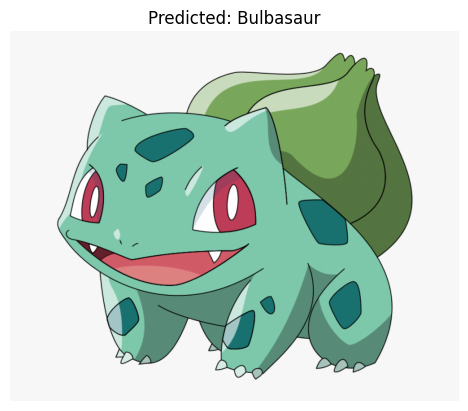

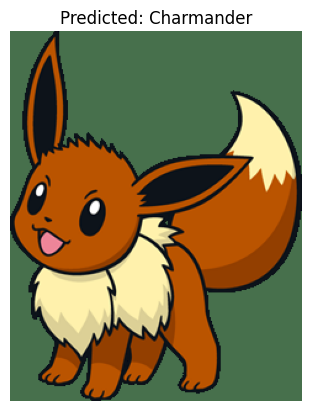

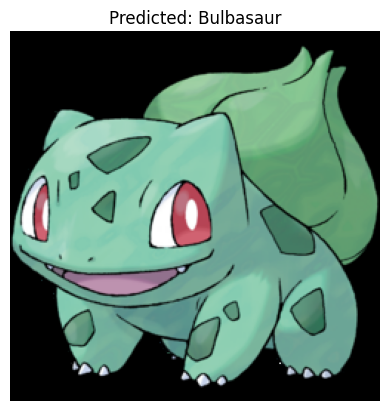

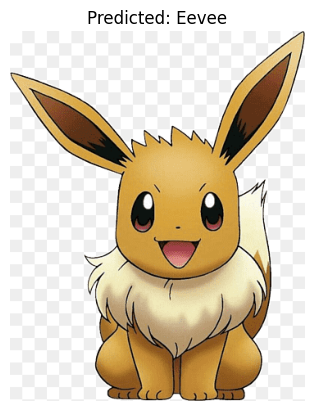

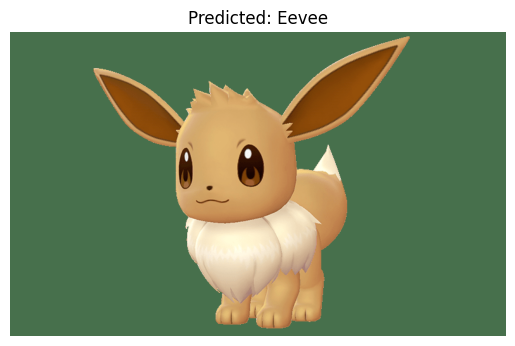

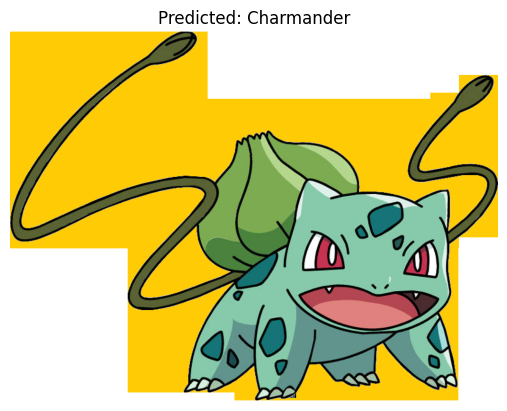

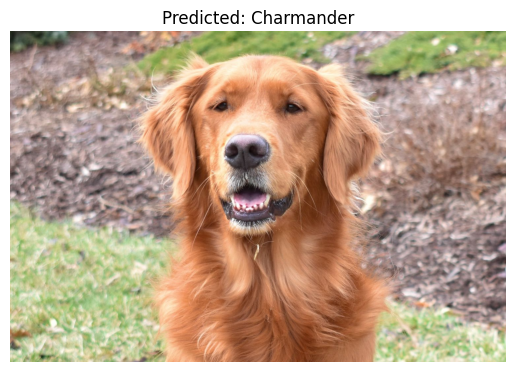

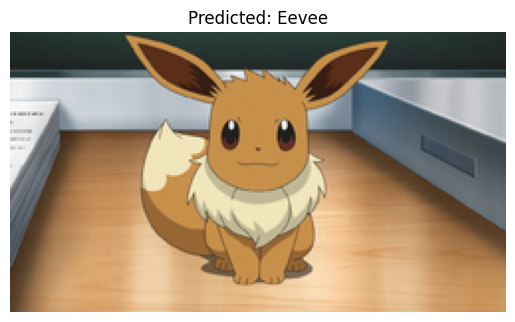

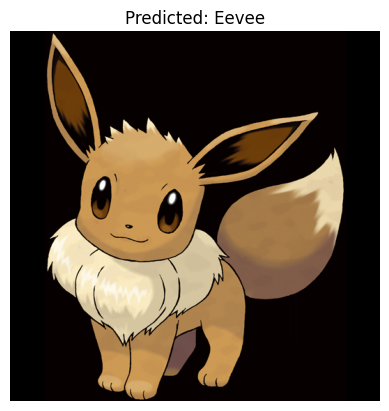

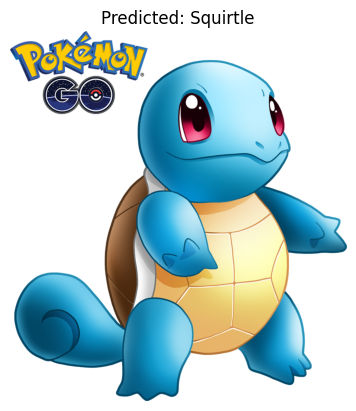

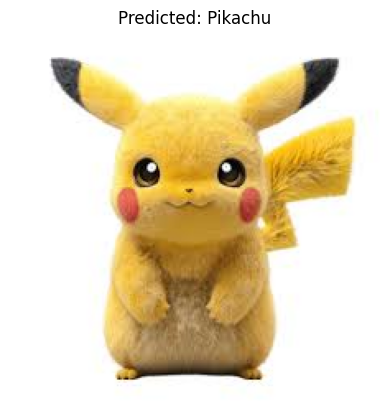

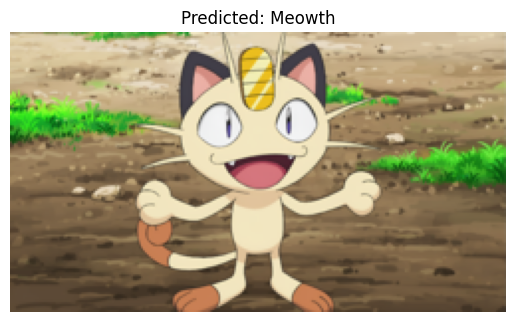

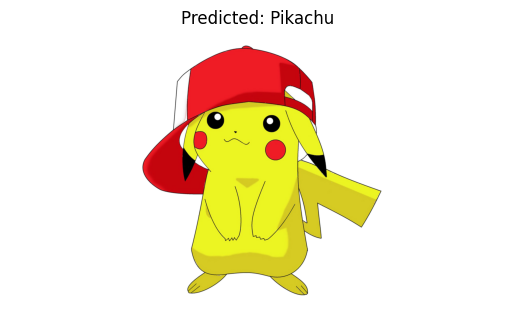

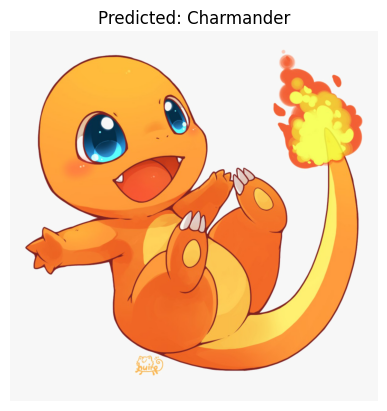

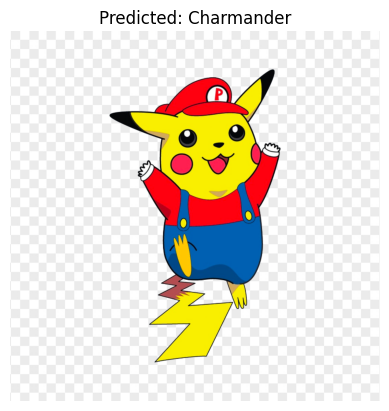

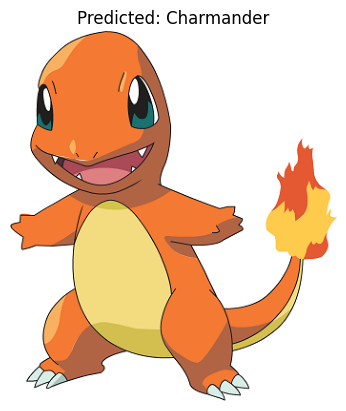

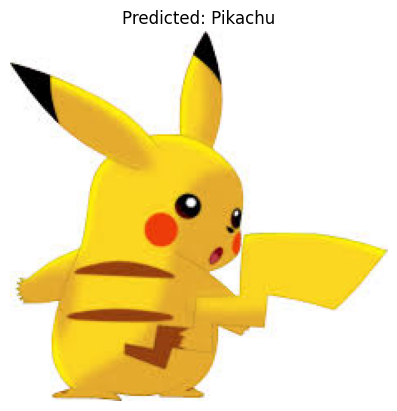

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def load_image(image_path):
    image = Image.open(image_path)
    image = image.convert('RGB')
    image_transformed = transform(image)
    image_transformed = image_transformed.unsqueeze(0)
    return image, image_transformed

image_folder = '/content/drive/MyDrive/Datasets/Pokemon_Pred'
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('.jpg', '.png'))]

net.eval()

with torch.no_grad():
    for img_path in image_paths:
        original_image, image = load_image(img_path)

        output = net(image)
        _, predicted = torch.max(output.data, 1)  # Get the predicted class
        predicted_class = class_names[predicted.item()]  # Get the class name

        # Display the image and prediction
        plt.imshow(original_image)
        plt.title(f'Predicted: {predicted_class}')
        plt.axis('off')
        plt.show()

Uploading picture of the pokemon may be difficult on a Macbook/Safari.

Saving png-clipart-pikachu-bymika-pikachu-illustration-thumbnail.png to png-clipart-pikachu-bymika-pikachu-illustration-thumbnail.png


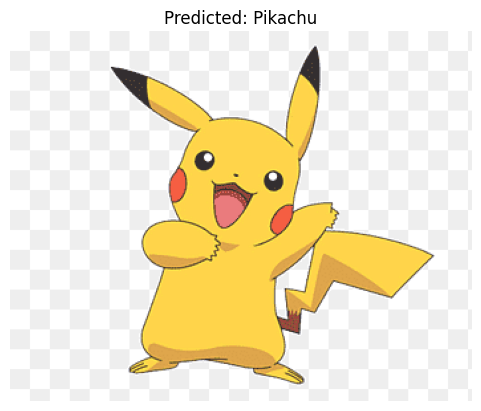

Do you want to upload another image? (y/n): y


Saving pngtree-charmander-clipart-pokemon-baby-illustration-firetype-art-vector-png-image_6799306.png to pngtree-charmander-clipart-pokemon-baby-illustration-firetype-art-vector-png-image_6799306.png


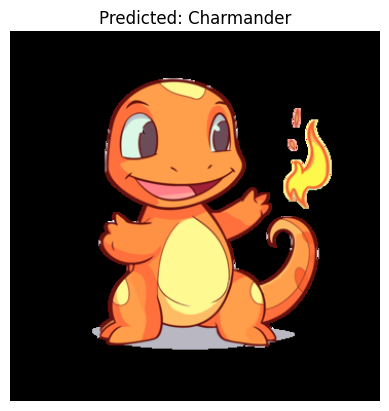

Do you want to upload another image? (y/n): y


Saving db905m6-4bce773e-2535-4c2e-b5c2-83e54c48bf59.png to db905m6-4bce773e-2535-4c2e-b5c2-83e54c48bf59.png


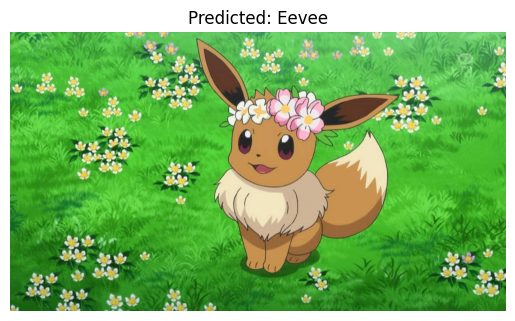

Do you want to upload another image? (y/n): y


Saving 5f28faa9e42aa627e0015d625b25cb8e.jpg to 5f28faa9e42aa627e0015d625b25cb8e.jpg


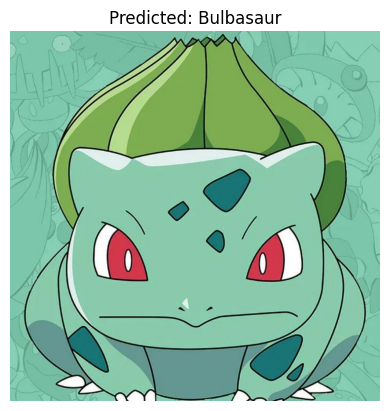

Do you want to upload another image? (y/n): y


Saving Meowth.webp to Meowth.webp


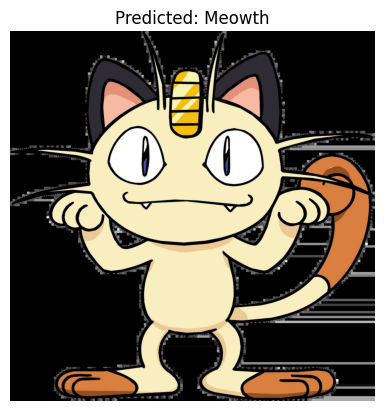

In [ ]:
from google.colab import files
import io

def upload_and_predict():
    while True:

        uploaded = files.upload()


        image_filename = next(iter(uploaded))

        def load_image(image_path):
            image = Image.open(image_path)
            image = image.convert('RGB')
            image_transformed = transform(image)
            image_transformed = image_transformed.unsqueeze(0)
            return image, image_transformed


        image_path = image_filename
        original_image, image_transformed = load_image(image_path)

        net.eval()
        with torch.no_grad():
            output = net(image_transformed)
            _, predicted = torch.max(output.data, 1)
            predicted_class = train_data.classes[predicted.item()]


        plt.imshow(original_image)
        plt.title(f'Predicted: {predicted_class}')
        plt.axis('off')
        plt.show()

        user_input = input("Do you want to upload another image? (y/n): ").strip().lower()
        if user_input != 'y':
            print("Exiting the program.")
            break

upload_and_predict()

